### Create Spark session

In [ ]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.2.1-bin-hadoop3.2"


import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession \
       .builder \
       .appName("Our First Spark Example") \
       .getOrCreate()

spark

### Create Data Frame

##### *Read file without header*

In [ ]:
dfcsv = spark.read.csv("postalcodes.csv")

dfcsv.show(10)

##### *Read CSV with header*


In [ ]:
# import file raw

dfcsv = spark.read.options(Header=True).csv("postalcodes.csv")

dfcsv.show(10)

#### *List in alternate way*

In [ ]:
dfcsv.show(3,0)

In [ ]:
# prompt: schema for dfcsv

dfcsv.printSchema()


#### *Read file poviding schema*

##### Create schema

In [ ]:
type(orderSchema)

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType, FloatType

orderSchema = StructType([
    StructField("SalesOrderNumber", StringType()),
    StructField("SalesOrderLineNumber", IntegerType()),
    StructField("OrderDate", DateType()),
    StructField("CustomerName", StringType()),
    StructField("Email", StringType()),
    StructField("Item", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("UnitPrice", FloatType()),
    StructField("Tax", FloatType())
    ])

##### Read File

In [ ]:
# Import file raw providing Schema

df = spark.read.format("csv").options(Header=True).load("postalcodes.csv")
df.show(30)

##### Selecting column

In [ ]:
dfstate = df.select('State')

dfstate.show(5)

df.show(5)

#### *Read json file*

In [ ]:
df = spark.read.option("multiline","true").json("customer.json")
df.show(3)
df.printSchema()

##### Access Nested Fields

In [ ]:
df.select("name", "address.city", "preferences.newsletter").show()

In [ ]:
from pyspark.sql.functions import explode

df_orders = df.select("customer_id", "name", explode("orders").alias("order"))

df_orders.select("customer_id", "name", "order.order_id", "order.item", "order.price").show()



### Exploring Data Frame

#### Getting info

In [ ]:
df.count()

#### Describe Data Frame

In [ ]:
df.describe().show()

#### Selecting columns

In [ ]:
df.select(df[1],df[2]).show(5)

### Using functions

[Pyspark Function](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/functions.html)

#### Generating columns


**Introduction to withColumn link to this section**

The withColumn function in Spark allows you to add a new column or replace an existing column in a DataFrame. It provides a flexible and expressive way to modify or derive new columns based on existing ones. With withColumn , you can apply transformations, perform computations, or create complex expressions to augment your data.

**Adding a New Column link to this section**

To add a new column using withColumn , you need to specify the name of the new column and the transformation or computation you want to apply.

In [ ]:
# Create the schema for the table
orderSchema = StructType([
    StructField("SalesOrderNumber", StringType()),
    StructField("SalesOrderLineNumber", IntegerType()),
    StructField("OrderDate", DateType()),
    StructField("CustomerName", StringType()),
    StructField("Email", StringType()),
    StructField("Item", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("UnitPrice", FloatType()),
    StructField("Tax", FloatType())
    ])

In [ ]:
# prompt: read file 2019.csv using orderSchema

df2019 = spark.read.format("csv").schema(orderSchema).options(Header=True).load("2019.csv")


In [ ]:
df.show(3,0)

##### Selecting and renaming column

In [ ]:
# Task: Select only CustomerName, Item, and Quantity
df_selected = df2019.select("CustomerName", "Item", "Quantity")

# Task: Rename 'CustomerName' to 'Client'
df_renamed = df_selected.withColumnRenamed("CustomerName", "Client")

df_renamed.show(5)

##### Creating new columns

In [ ]:
from pyspark.sql.functions import col
df=df2019
# Task: Create a new column 'TotalPrice' = Quantity * UnitPrice
df_total = df.withColumn("TotalPrice", col("Quantity") * col("UnitPrice"))

df_total.select("SalesOrderNumber", "Item", "Quantity", "UnitPrice", "TotalPrice").show(5)


##### Conditional Columns and Cleaning

In [ ]:
from pyspark.sql.functions import when

# Task: Add a column 'OrderCategory'
# If TotalPrice >= 500 → 'High Value', else 'Regular'
df_category = df_total.withColumn(
    "OrderCategory",
    when(col("TotalPrice") >= 500, "High Value").otherwise("Regular")
)

# Task: Replace null CustomerName with 'Unknown'
df_clean = df_category.fillna({"CustomerName": "Unknown"})

df_clean.select("CustomerName", "Item", "TotalPrice", "OrderCategory").show(5)


**Replacing an Existing Column link to this section**

withColumn can also be used to replace an existing column in a DataFrame

In [ ]:
from pyspark.sql.functions import when,lit, col, current_timestamp, input_file_name

dfWithNewColumn = df.withColumn("lot", when(col("Quantity") >= 100, "a lot").otherwise("not a lot"))

dfWithNewColumn.show(5,0)

##### Apply some function

In [ ]:
from pyspark.sql.functions import upper

dfWithUppercaseName = df.withColumn("CustomerName", upper(col("CustomerName")))
dfWithUppercaseName.show(3)


In [ ]:
from pyspark.sql.functions import lower

dfWithLowercaseName = df.withColumn("CustomerName", lower(col("CustomerName")))
dfWithLowercaseName.show(3)


In [ ]:
from pyspark.sql.functions import initcap

dfWithInitcapcaseName = df.withColumn("CustomerName", initcap(col("CustomerName")))
dfWithInitcapcaseName.show(3)

#### Dropping columns

In [ ]:
df_pyspark = df
df_pyspark = df_pyspark.drop("Email")
df_pyspark.show(5)

#### Using functions

[Pyspark Function](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/functions.html)

In [ ]:
from pyspark.sql.functions import when,lit, col, current_timestamp, input_file_name

 # Add columns IsFlagged, CreatedTS and ModifiedTS
df = df.withColumn("FileName", input_file_name())

df.show(5,0)


In [ ]:
df =df.withColumn("CreatedTS", current_timestamp()).withColumn("ModifiedTS", current_timestamp())


##### Working with TS

In [ ]:
# Add specific columns

df.select("CreatedTS","ModifiedTS").show(3,0)

##### Joking with column

In [ ]:
desired_column=df.columns[-5:]

In [ ]:
type(desired_column)

In [ ]:
print(desired_column)

In [ ]:
df.select(df.columns[-5:]).show(3,0)

In [ ]:
df.select("CustomerName").show(5,0)

In [ ]:
df.where(df.CustomerName.isNotNull()).show(10,0)
df.where(df.CustomerName.isNotNull()).count()

In [ ]:
df.where(df.CustomerName.isNull()).show(10,0)


In [ ]:
df.where(df.CustomerName.isNull()).count()

In [ ]:
df.filter(df.CustomerName == "").show(1)
df.filter(df.CustomerName == "").count()


In [ ]:
df.filter(df.CustomerName != "").show(1)
df.filter(df.CustomerName != "").count()


In [ ]:
from pyspark.sql.functions import when,lit, col, current_timestamp, input_file_name

# Update CustomerName to "Unknown" if CustomerName null or empty
dfnew2 = df.withColumn("CustomerName", when(col("CustomerName").isNull(),lit("Unknown")).otherwise(col("CustomerName")))

dfnew2.show(3)

### Cleaning Data

#### Handle null values

In [ ]:
# Drop rows with null values in the "CustomerName" column
df_filtered_nn = df.filter(col("CustomerName").isNotNull())
# Show the resulting DataFrame
df_filtered_nn.show(5)

df_filtered_nn.count()


In [ ]:
# Drop rows with null values in the "CustomerName" column
df_filtered_null = df.filter(col("CustomerName").isNull())
# Show the resulting DataFrame
df_filtered_null.show(5)

df_filtered_null.count()


#### Handle missing values

In [ ]:
df_pyspark = df
df_pyspark.show(5)
df_pyspark.count()

#### Remove null value

In [ ]:
df_pyspark.na.drop().count()

#### Filling null values

In [ ]:
df_pyspark.na.fill("Missing").show()

### Using SQL

In [ ]:
df.show(2)

In [ ]:
## Assuming you have a PySpark DataFrame named "df"
df.createOrReplaceTempView("customerdata")

In [ ]:
# SQL Select query
spark.sql("SELECT *  FROM customerdata").show(5)

#### Catalog concept

Il catalogo in Spark è il “registro centrale” dei metadati: gestisce informazioni su database, tabelle, viste e funzioni, rendendo più semplice scoprire e organizzare i dati all’interno di un’applicazione Spark.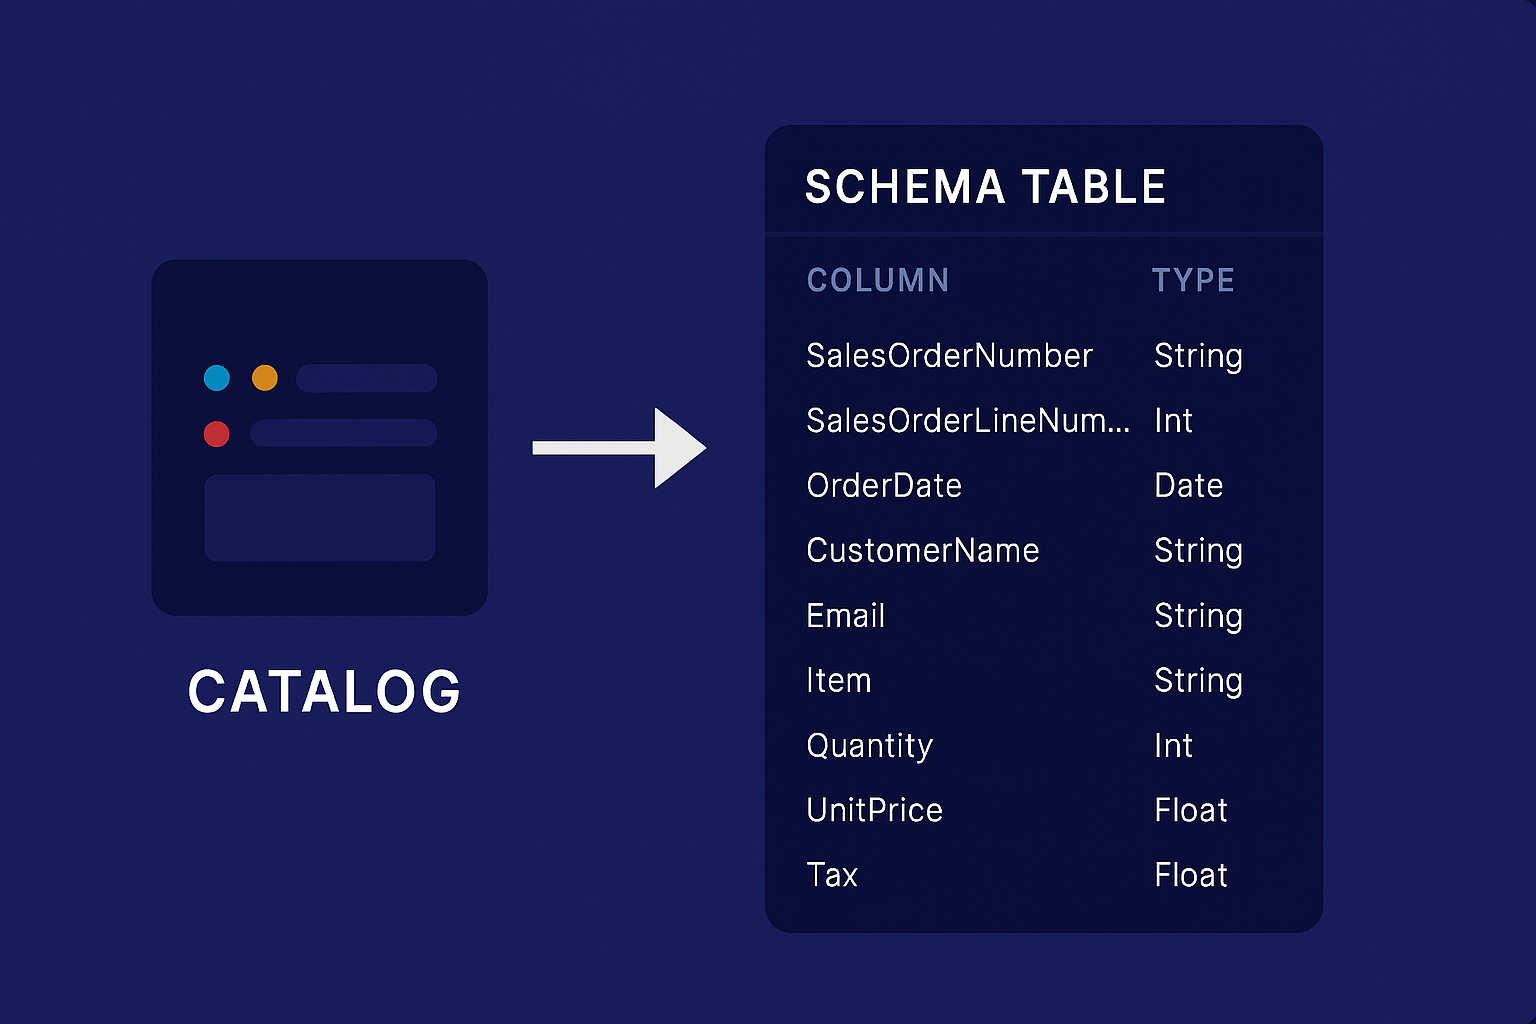

##### Catalog

In [ ]:
spark.catalog.currentCatalog()

In [ ]:
spark.catalog.listCatalogs()

##### Database

In [ ]:
spark.catalog.currentDatabase()

In [ ]:
spark.catalog.listDatabases()

##### Tables

In [ ]:
spark.catalog.listTables("default")

#### SQL vs. SPARK

In [ ]:
# Create DataFrame
df = spark.read \
          .option("header",True) \
          .csv("./postalcodes.csv")
df.printSchema()
df.show(3)


In [ ]:
# Create SQL table
spark.read \
          .option("header",True) \
          .csv("./postalcodes.csv") \
          .createOrReplaceTempView("Zipcodes")


In [ ]:
# Select query
df.select("city","zip","state").show(5)

spark.sql("SELECT  city, zip, state FROM ZIPCODES").show(5)


In [ ]:
# where
df.select("city","zip","state") \
  .where("state == 'AZ'") \
  .show(5)

spark.sql(""" SELECT  city, zip, state FROM ZIPCODES
          WHERE state = 'AZ' """) \
     .show(5)

In [ ]:
# sorting
df.select("city","zip","state") \
  .where("state in ('PR','AZ','FL')") \
  .orderBy("state") \
  .show(10)

spark.sql(""" SELECT  city, zip, state FROM ZIPCODES
          WHERE state in ('PR','AZ','FL') order by state """) \
     .show(10)

In [ ]:
# grouping
df.groupBy("state").count() \
  .show(3)

spark.sql(""" SELECT state, count(*) as count FROM ZIPCODES
          GROUP BY state""") \
     .show(3)